# Q0 – Data preparation with dummy encoding

---

In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("2176120.csv")

In [5]:
print("-----INFO-----")
print(df.info())
print("\n-----SHAPE-----")
print(df.shape)
print("\n-----FIRST ROWS-----")
print(df.head())

-----INFO-----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   survey_id           826 non-null    object 
 1   gender              850 non-null    object 
 2   living_arrangement  850 non-null    object 
 3   exercise_frequency  850 non-null    object 
 4   screen_time         850 non-null    float64
 5   caffeinated_drinks  839 non-null    float64
 6   cigarettes          850 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 46.6+ KB
None

-----SHAPE-----
(850, 7)

-----FIRST ROWS-----
                              survey_id  gender living_arrangement  \
0  86dfec63-0096-4764-9584-c842e40e30fa    male    student_housing   
1  d212b539-f1df-4e7e-8b0e-e2429d2202f3    male    student_housing   
2  f1896a91-7d08-43b6-93ab-b95ea2427d9b    male            parents   
3  97fd9721-ca5e-4038-9400-0e8d223953f4    m

In [6]:
print("\n-----MISSING VALUES-----")
print(df.isna().sum())


-----MISSING VALUES-----
survey_id             24
gender                 0
living_arrangement     0
exercise_frequency     0
screen_time            0
caffeinated_drinks    11
cigarettes             0
dtype: int64


In [8]:
df_clean = df.dropna()
print(f"\nNumber of rows after removing missing values: {len(df_clean)}")


Number of rows after removing missing values: 816


In [11]:
duplicates = df_clean.duplicated().sum()
print(f"Number of duplicates: {duplicates}")
df_clean = df_clean.drop_duplicates()

Number of duplicates: 0


In [13]:
categorical_cols = ['gender', 'living_arrangement', 'exercise_frequency']
for col in categorical_cols:
    print(f"\nUnique values in {col}: {df_clean[col].unique()}")

df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)


Unique values in gender: ['male' 'female']

Unique values in living_arrangement: ['student_housing' 'parents']

Unique values in exercise_frequency: ['low' 'high' 'average']


In [18]:
print("\n-----DATATYPES AFTER ENCODING-----")
print(df_encoded.dtypes)
print("\n-----ENCODED DATA SAMPLE-----")
print(df_encoded.head())
df_encoded.to_csv("2176120_cleaned_encoded.csv", index=False)


-----DATATYPES AFTER ENCODING-----
survey_id                              object
screen_time                           float64
caffeinated_drinks                    float64
cigarettes                              int64
gender_male                              bool
living_arrangement_student_housing       bool
exercise_frequency_high                  bool
exercise_frequency_low                   bool
dtype: object

-----ENCODED DATA SAMPLE-----
                              survey_id  screen_time  caffeinated_drinks  \
0  86dfec63-0096-4764-9584-c842e40e30fa          3.9                18.0   
1  d212b539-f1df-4e7e-8b0e-e2429d2202f3          2.6                13.0   
2  f1896a91-7d08-43b6-93ab-b95ea2427d9b          1.9                11.0   
3  97fd9721-ca5e-4038-9400-0e8d223953f4          4.4                15.0   
4  3a66adef-6565-4639-89e2-519bed9b1c5f          3.5                14.0   

   cigarettes  gender_male  living_arrangement_student_housing  \
0           9         True  

---

---

---

# Q1 – Smoking behavior

---

### Q1a – Smoking behavior: descriptive statistics

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("2176120_cleaned_encoded.csv")

# Descriptive statistics for the whole sample
print("---- OVERALL SAMPLE ----")
mean_all = np.mean(df['cigarettes'])
median_all = np.median(df['cigarettes'])
std_all = np.std(df['cigarettes'], ddof=1)
range_all = np.max(df['cigarettes']) - np.min(df['cigarettes'])
mode_all = df['cigarettes'].mode()[0]

print(f"Mean: {mean_all:.2f}")
print(f"Median: {median_all:.2f}")
print(f"Std dev: {std_all:.2f}")
print(f"Range: {range_all:.2f}")
print(f"Mode (all students): {mode_all}")

---- OVERALL SAMPLE ----
Mean: 1.62
Median: 0.00
Std dev: 3.05
Range: 11.00
Mode (all students): 0


In [23]:
# Subset: smokers only
df_smokers = df[df['cigarettes'] > 0]
print("\n---- SMOKERS ONLY ----")
mean_smokers = np.mean(df_smokers['cigarettes'])
median_smokers = np.median(df_smokers['cigarettes'])
std_smokers = np.std(df_smokers['cigarettes'], ddof=1)
range_smokers = np.max(df_smokers['cigarettes']) - np.min(df_smokers['cigarettes'])
mode_smokers = df_smokers['cigarettes'].mode()[0]
print(f"Mean: {mean_smokers:.2f}")
print(f"Median: {median_smokers:.2f}")
print(f"Std dev: {std_smokers:.2f}")
print(f"Range: {range_smokers:.2f}")
print(f"Mode (smokers only): {mode_smokers}")


---- SMOKERS ONLY ----
Mean: 6.84
Median: 7.00
Std dev: 1.89
Range: 9.00
Mode (smokers only): 7


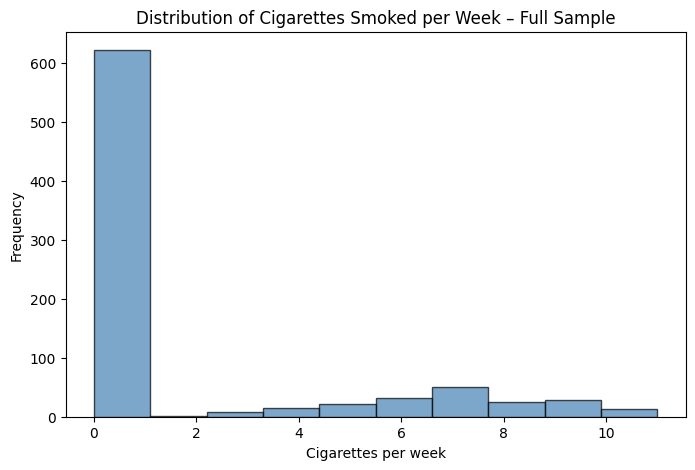

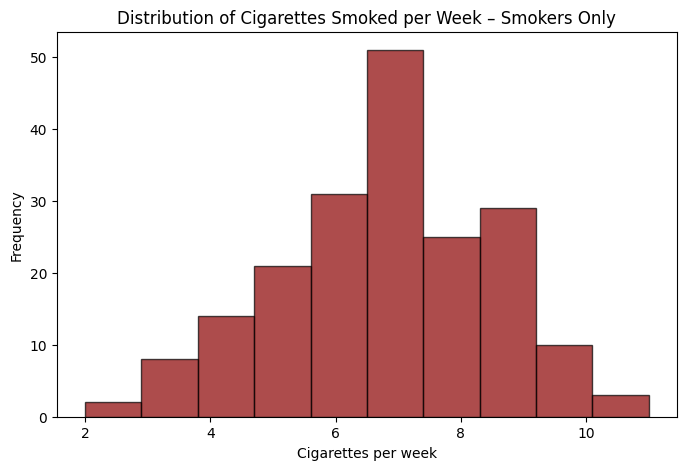

In [21]:
# Visualization
plt.figure(figsize=(8,5))
plt.hist(df['cigarettes'], bins=10, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Cigarettes Smoked per Week – Full Sample')
plt.xlabel('Cigarettes per week')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df_smokers['cigarettes'], bins=10, color='darkred', edgecolor='black', alpha=0.7)
plt.title('Distribution of Cigarettes Smoked per Week – Smokers Only')
plt.xlabel('Cigarettes per week')
plt.ylabel('Frequency')
plt.show()

---

### Q1b – Distribution fit and skewness

Skewness: -0.21


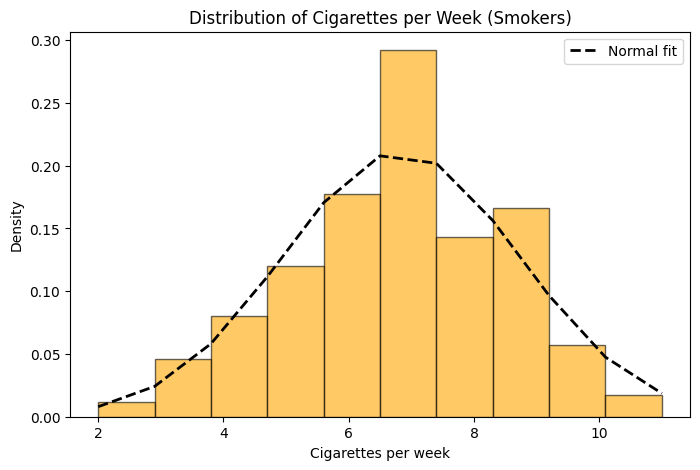

In [25]:
from scipy.stats import norm, poisson, expon, probplot

# Use only smokers
data = df_smokers['cigarettes']

# Compute skewness
skew_value = data.skew()
print(f"Skewness: {skew_value:.2f}")

# Plot histogram + normal PDF overlay
plt.figure(figsize=(8,5))
count, bins, ignored = plt.hist(data, bins=10, density=True, color='orange', edgecolor='black', alpha=0.6)
mu, sigma = norm.fit(data)
plt.plot(bins, norm.pdf(bins, mu, sigma), 'k--', linewidth=2, label='Normal fit')
plt.title('Distribution of Cigarettes per Week (Smokers)')
plt.xlabel('Cigarettes per week')
plt.ylabel('Density')
plt.legend()
plt.show()


---

### Q1c – Gender Differences in Smoking

In [28]:
data["smoker"] = np.where(data["cigarettes"] > 0, 1, 0)


In [29]:
contingency = pd.crosstab(data["gender"], data["smoker"])
print(contingency)


smoker    0    1
gender          
female  285   95
male    365  105


In [32]:
print(f"Counts – males: 470, male smokers: 105 ")
print(f"Counts – females: 380, female smokers: 95")
print(f"P(smokes | male)   = {105/470}")
print(f"P(smokes | female) = {95/380}")

Counts – males: 470, male smokers: 105 
Counts – females: 380, female smokers: 95
P(smokes | male)   = 0.22340425531914893
P(smokes | female) = 0.25


---

---

---

# Q2 – Stress and Smoking

---

### Q2a – Stress and Smoking (Derivative Analysis)

Derivative of C(s): 19.6 - 3.92*s
Critical point (stress level): [5.00000000000000]
Maximum number of cigarettes per week: 49.0000000000000


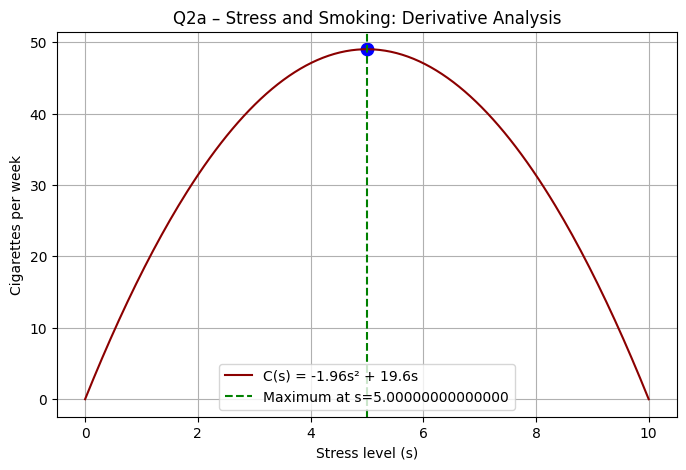

In [33]:
# Q2a – Derivative Analysis: Maximum Smoking Level
# Following FMSR Class 2 – Basic Math (Derivatives and Extrema)

import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, diff, solve

# Define variable
s = symbols('s')

# Define the function
C = -1.96*s**2 + 19.6*s

# Compute derivative
dC_ds = diff(C)
print("Derivative of C(s):", dC_ds)

# Solve for critical point (where derivative = 0)
critical_point = solve(dC_ds, s)
print("Critical point (stress level):", critical_point)

# Compute maximum value of C(s)
C_max = C.subs(s, critical_point[0])
print("Maximum number of cigarettes per week:", C_max)

# Plot the function
s_vals = np.linspace(0, 10, 200)
C_vals = -1.96*s_vals**2 + 19.6*s_vals

plt.figure(figsize=(8, 5))
plt.plot(s_vals, C_vals, color='darkred', label='C(s) = -1.96s² + 19.6s')
plt.axvline(float(critical_point[0]), color='green', linestyle='--', label=f'Maximum at s={critical_point[0]}')
plt.scatter(float(critical_point[0]), float(C_max), color='blue', s=80)
plt.title("Q2a – Stress and Smoking: Derivative Analysis")
plt.xlabel("Stress level (s)")
plt.ylabel("Cigarettes per week")
plt.legend()
plt.grid(True)
plt.show()


---

### Q2b – Stress and Smoking

Total cigarettes smoked (0 ≤ s ≤ 5): 163.33


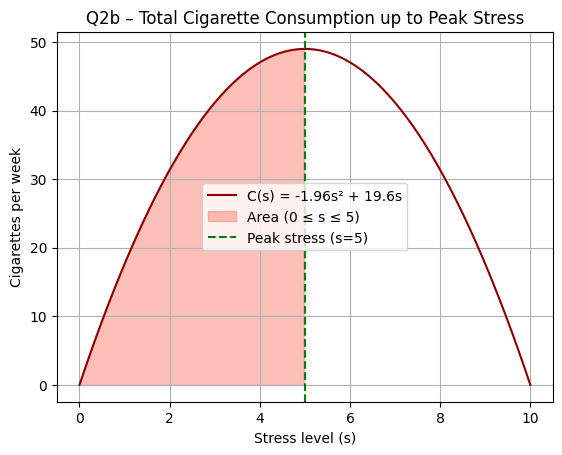

In [34]:
# Q2b – Integral Analysis (0 ≤ s ≤ 5)
# Based on FMSR Class 2 – Basic Math: Integration and Area Under the Curve

import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

# Define the function
def C(s):
    return -1.96*s**2 + 19.6*s

# Compute definite integral from 0 to 5
total_cigarettes, error = quad(C, 0, 5)
print(f"Total cigarettes smoked (0 ≤ s ≤ 5): {total_cigarettes:.2f}")

# Plot the curve and shaded area
s = np.linspace(0, 10, 200)
plt.plot(s, C(s), color='darkred', label='C(s) = -1.96s² + 19.6s')
plt.fill_between(s, C(s), where=(s <= 5), color='salmon', alpha=0.5, label='Area (0 ≤ s ≤ 5)')
plt.axvline(5, color='green', linestyle='--', label='Peak stress (s=5)')
plt.title("Q2b – Total Cigarette Consumption up to Peak Stress")
plt.xlabel("Stress level (s)")
plt.ylabel("Cigarettes per week")
plt.legend()
plt.grid(True)
plt.show()


---

---

---

---

# Q3 – Differences Between Groups

---

### Q3a – Living Arrangement and Smoking

Descriptive statistics by group:
                                    count      mean       std  min  25%  50%  \
living_arrangement_student_housing                                             
False                               496.0  0.879032  2.387147  0.0  0.0  0.0   
True                                320.0  2.781250  3.574854  0.0  0.0  0.0   

                                    75%   max  
living_arrangement_student_housing             
False                               0.0  11.0  
True                                6.0  11.0  


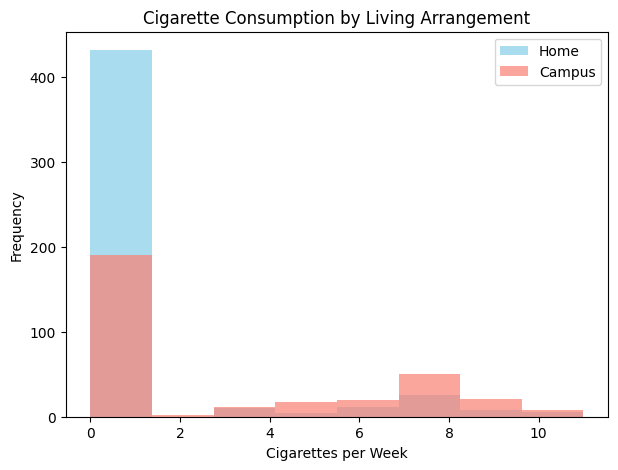

In [3]:
# Q3a – Living Arrangement and Smoking Behavior
# Corrected column name: 'living_arrangement_student_housing'

import pandas as pd
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("2176120_cleaned_encoded.csv")

# Separate groups
campus = df[df["living_arrangement_student_housing"] == 1]["cigarettes"]
home = df[df["living_arrangement_student_housing"] == 0]["cigarettes"]

# Descriptive statistics
print("Descriptive statistics by group:")
print(df.groupby("living_arrangement_student_housing")["cigarettes"].describe())

# Visual comparison
plt.figure(figsize=(7,5))
plt.hist(home, bins=8, alpha=0.7, label="Home", color='skyblue')
plt.hist(campus, bins=8, alpha=0.7, label="Campus", color='salmon')
plt.title("Cigarette Consumption by Living Arrangement")
plt.xlabel("Cigarettes per Week")
plt.ylabel("Frequency")
plt.legend()
plt.show()




In [41]:
# Independent samples t-test (one-tailed: campus > home)
t_stat, p_value = ttest_ind(campus, home, alternative='greater')

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("Students living on campus smoke significantly more.")
else:
    print("No significant difference between home and campus students.")

T-statistic: 9.114
P-value: 0.000
Students living on campus smoke significantly more.


---

### Q3b – Exercise Frequency and Smoking Behavior

In [46]:
# Q3b – Exercise Frequency and Smoking (using dummy variables)
# Columns: exercise_frequency_high, exercise_frequency_low

import pandas as pd
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

# Load cleaned data
df = pd.read_csv("2176120_cleaned_encoded.csv")

# Define groups based on dummy columns
low = df[df["exercise_frequency_low"] == 1]["cigarettes"]
high = df[df["exercise_frequency_high"] == 1]["cigarettes"]
average = df[(df["exercise_frequency_low"] == 0) & (df["exercise_frequency_high"] == 0)]["cigarettes"]

# Check counts
print(f"Low exercise group: {len(low)} students")
print(f"Average exercise group: {len(average)} students")
print(f"High exercise group: {len(high)} students")

# Descriptive stats
print("\nDescriptive statistics:")
print(df.groupby(["exercise_frequency_low", "exercise_frequency_high"])["cigarettes"].describe())

# One-way ANOVA
f_stat, p_value = f_oneway(low, average, high)
print(f"\nF-statistic: {f_stat:.3f}, p-value: {p_value:.3f}")




Low exercise group: 254 students
Average exercise group: 159 students
High exercise group: 403 students

Descriptive statistics:
                                                count      mean       std  \
exercise_frequency_low exercise_frequency_high                              
False                  False                    159.0  1.823899  3.199158   
                       True                     403.0  0.377171  1.624341   
True                   False                    254.0  3.480315  3.674182   

                                                min  25%  50%  75%   max  
exercise_frequency_low exercise_frequency_high                            
False                  False                    0.0  0.0  0.0  3.0  10.0  
                       True                     0.0  0.0  0.0  0.0   9.0  
True                   False                    0.0  0.0  3.0  7.0  11.0  

F-statistic: 100.613, p-value: 0.000


---

---

---

---

# Q4 – Caffeine Consumption

---

### Q4a – Caffeine Consumption: Exponential Model and Rate of Change

In [6]:
a = df["caffeinated_drinks"].max()
print("Maximum observed caffeine consumption (a):", a)

Maximum observed caffeine consumption (a): 22.0


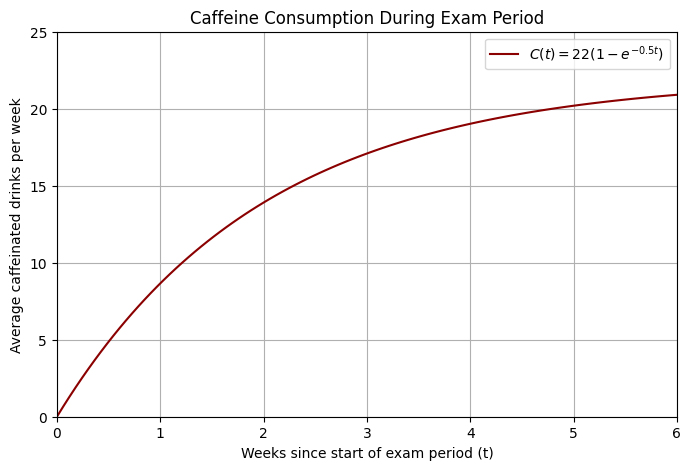

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

a = 22    
b = 0.5    
t = np.linspace(0, 6, 100)  

C_t = a * (1 - np.exp(-b * t))

plt.figure(figsize=(8,5))
plt.plot(t, C_t, color='darkred', label=r"$C(t) = 22(1 - e^{-0.5t})$")
plt.title("Caffeine Consumption During Exam Period")
plt.xlabel("Weeks since start of exam period (t)")
plt.ylabel("Average caffeinated drinks per week")
plt.ylim(0, 25)
plt.xlim(0, 6)
plt.grid(True)
plt.legend()
plt.show()


---

### Q4B – Rate of Change in Caffeine Consumption

In [ ]:
import sympy as sp


t = sp.Symbol('t', real=True)
a, b = 22, 0.5
C = a * (1 - sp.exp(-b * t))


C_derivative = sp.diff(C, t)
print("Symbolic derivative C'(t):")
sp.pprint(C_derivative)


C_simplified = sp.simplify(C_derivative)
print("\nSimplified:")
sp.pprint(C_simplified)


Symbolic derivative C'(t):
      -0.5⋅t
11.0⋅ℯ      

Simplified:
      -0.5⋅t
11.0⋅ℯ      


In [11]:
import numpy as np

def dC_dt(t):
    return 11 * np.exp(-0.5 * t)

for week in [0, 1, 2, 4, 6]:
    print(f"Week {week}: dC/dt = {dC_dt(week):.2f}")


Week 0: dC/dt = 11.00
Week 1: dC/dt = 6.67
Week 2: dC/dt = 4.05
Week 4: dC/dt = 1.49
Week 6: dC/dt = 0.55


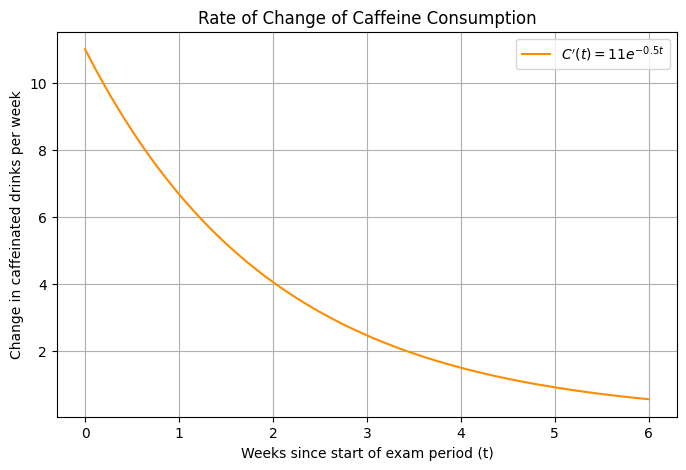

In [12]:
# Hodnoty pro graf
t = np.linspace(0, 6, 100)
dC = dC_dt(t)

# Vykreslení derivace
plt.figure(figsize=(8,5))
plt.plot(t, dC, color='darkorange', label=r"$C'(t) = 11e^{-0.5t}$")
plt.title("Rate of Change of Caffeine Consumption")
plt.xlabel("Weeks since start of exam period (t)")
plt.ylabel("Change in caffeinated drinks per week")
plt.grid(True)
plt.legend()
plt.show()


---

# Q5 – Screen Time

---

### Q5a – Screen Time: Descriptive Statistics

Mean screen time: 3.14
Std dev: 0.88
Median: 3.1
Range: 5.7 (0.5–6.2 hours)


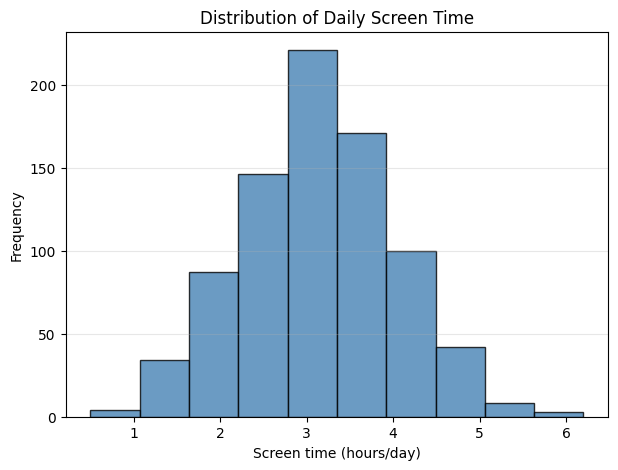

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("2176120_cleaned_encoded.csv")

# Basic descriptives for screen time
mean_screen = np.mean(df["screen_time"])
std_screen = np.std(df["screen_time"], ddof=1)
median_screen = np.median(df["screen_time"])
min_screen = np.min(df["screen_time"])
max_screen = np.max(df["screen_time"])
rng_screen = max_screen - min_screen

print("Mean screen time:", round(mean_screen, 2))
print("Std dev:", round(std_screen, 2))
print("Median:", round(median_screen, 2))
print("Range:", round(rng_screen, 2), f"({min_screen}–{max_screen} hours)")

# Histogram
plt.figure(figsize=(7,5))
plt.hist(df["screen_time"], bins=10, color='steelblue', edgecolor='black', alpha=0.8)
plt.title("Distribution of Daily Screen Time")
plt.xlabel("Screen time (hours/day)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()


In [18]:


from scipy.stats import norm
import numpy as np
import pandas as pd

# Load dataset
df = pd.read_csv("2176120_cleaned_encoded.csv")

# Compute parameters
mu = 3.5
sigma = 1.2

# Target threshold
x = 1.5

# Probability calculation
p_less_1_5 = norm.cdf(x, loc=mu, scale=sigma)
print(f"Mean: {mu:.2f}, Std dev: {sigma:.2f}")
print(f"Probability (screen_time < 1.5h): {p_less_1_5:.4f}")


Mean: 3.50, Std dev: 1.20
Probability (screen_time < 1.5h): 0.0478


----

### Question 5b – Identifying high screen-time users

In [4]:
from scipy.stats import norm

mu = 3.50
sigma = 1.20

p90 = norm.ppf(0.90, loc=mu, scale=sigma)
print(f"90th percentile (top 10%): {p90:.2f} h/day")


90th percentile (top 10%): 5.04 h/day


---

### Q5c – Mean Screen Time and Margin of Error

In [5]:
# Q5c – Mean Screen Time and Margin of Error
# Based on FMSR Class 5 – Inferential Statistics

import pandas as pd
import numpy as np
from scipy.stats import norm

# Load dataset
df = pd.read_csv("2176120_cleaned_encoded.csv")

# Parameters
x_bar = np.mean(df["screen_time"])
s = np.std(df["screen_time"], ddof=1)
n = len(df["screen_time"])
z = 1.96  # for 95% confidence

# Margin of Error
MoE = z * (s / np.sqrt(n))

# Confidence interval
lower = x_bar - MoE
upper = x_bar + MoE

print(f"Sample mean: {x_bar:.2f} h/day")
print(f"Standard deviation: {s:.2f}")
print(f"Sample size: {n}")
print(f"Margin of Error: ±{MoE:.2f}")
print(f"95% Confidence Interval: ({lower:.2f}, {upper:.2f})")


Sample mean: 3.14 h/day
Standard deviation: 0.88
Sample size: 816
Margin of Error: ±0.06
95% Confidence Interval: (3.08, 3.20)


---

---

---

---

# Q6 - Smoking policy effectiveness

---

### Q6a – Probability of Smoking Fewer Than 5 Cigarettes per Week

In [6]:
# Q6a – Probability that a student smokes fewer than 5 cigarettes per week
# Based on FMSR Class 3: Probabilities (Normal Distribution)

import pandas as pd
import numpy as np
from scipy.stats import norm

# Load dataset
df = pd.read_csv("2176120_cleaned_encoded.csv")

# Calculate parameters
mu = np.mean(df["cigarettes"])
sigma = np.std(df["cigarettes"], ddof=1)
x = 5  # threshold

# Compute probability
p_less_5 = norm.cdf(x, loc=mu, scale=sigma)

print(f"Mean cigarettes/week: {mu:.2f}")
print(f"Standard deviation: {sigma:.2f}")
print(f"P(X < 5): {p_less_5:.4f}")


Mean cigarettes/week: 1.62
Standard deviation: 3.05
P(X < 5): 0.8654


---

### Q6b – Comparison of Smoking Probability by Exercise Frequency

In [7]:
# Q6b – Is the probability of smoking <5 higher for frequent exercisers?
# Based on FMSR Class 5 – Inferential Statistics (Two-Proportion Z-Test)

import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

df = pd.read_csv("2176120_cleaned_encoded.csv")

# Create smoker flag (1 if <5 cigarettes/week)
df["smokes_less_5"] = (df["cigarettes"] < 5).astype(int)

# Define groups
freq_ex = df[df["exercise_frequency_high"] == 1]      # frequent exercisers
low_ex  = df[df["exercise_frequency_low"] == 1]       # infrequent exercisers

# Count “successes” and sample sizes
count = np.array([freq_ex["smokes_less_5"].sum(),
                  low_ex["smokes_less_5"].sum()])
nobs  = np.array([len(freq_ex), len(low_ex)])

# Perform one-tailed z-test (p1>p2)
z_stat, p_val = proportions_ztest(count=count, nobs=nobs, alternative='larger')

print(f"Frequent exercise: {count[0]}/{nobs[0]} = {count[0]/nobs[0]:.3f}")
print(f"Infrequent exercise: {count[1]}/{nobs[1]} = {count[1]/nobs[1]:.3f}")
print(f"Z-statistic: {z_stat:.3f}, p-value: {p_val:.4f}")


Frequent exercise: 383/403 = 0.950
Infrequent exercise: 141/254 = 0.555
Z-statistic: 12.278, p-value: 0.0000


---

### Q6c – Follow-up survey and policy effect

In [ ]:
Old = p_less_5
New = 8/50
if Old > New:
    print("No, this new data does not provide evidence that the smoking policy is having a positive effect.")
else:
    print("Yes, it has a positiv efect")


0.8654465521085758
0.16
No, this new data does not provide evidence that the smoking policy is having a positive effect.


---

### Q6d – Likelihood That p > 0.75 Given the New Data

In [17]:
# Q6d – Likelihood that true p > 0.75
# Based on FMSR Class 5 – Inferential Statistics (Confidence interval for a proportion)

import numpy as np
from scipy.stats import norm

# New survey data
x = 8
n = 50
p_hat = x / n
z = 1.96   # 95% confidence

# Confidence interval
se = np.sqrt(p_hat * (1 - p_hat) / n)
lower = p_hat - z * se
upper = p_hat + z * se

print(f"Sample proportion (p̂): {p_hat:.2f}")
print(f"95% CI for true p: ({lower:.3f}, {upper:.3f})")

# Probability that true p exceeds 0.75 (approx via normal)
prob_p_above_75 = 1 - norm.cdf(0.75, loc=p_hat, scale=se)
print(f"P(p > 0.75) ≈ {prob_p_above_75:.6f}")


Sample proportion (p̂): 0.16
95% CI for true p: (0.058, 0.262)
P(p > 0.75) ≈ 0.000000
